# Gas Sensor Array Drift at Different Concentrations
## Regression Track — Review 1

### Objective

The objective of this regression task is to predict the **gas concentration level** from
chemical sensor array measurements.

The dataset (UCI ID 270) contains measurements from 16 chemical sensors exposed to
6 different gases across 10 batches. Each measurement is described by 128 sensor-derived features.

### Regression Algorithms Implemented

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor (SVR)
10. K-Nearest Neighbors Regressor

### Evaluation Metrics

All models are evaluated using: **R² Score**, **RMSE**, **MAE**.
5-fold cross-validated R² is reported for the two best-performing models.

In [46]:
import sys
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Also add src/ so data_loader can be imported directly
sys.path.append(str(PROJECT_ROOT / "src"))


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_dataset, add_gas_names

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Dataset Loading and Audit

In [47]:
# Load all 10 batch .dat files
df = load_dataset(PROJECT_ROOT / "data")

# Add readable gas names (Ethanol, Ethylene, etc.)
df = add_gas_names(df)

# Define the 128 sensor feature columns once — used throughout the notebook
feature_columns = [f"Feature{i}" for i in range(1, 129)]

print("Dataset shape:", df.shape)
print("Number of sensor features:", len(feature_columns))

Looking for dataset in:
d:\dev\projs\ML-Review_Project\gas_sensor_ml_capstone\data

Found 10 .dat files.

Loading: batch1.dat
  Samples loaded: 445
Loading: batch10.dat
  Samples loaded: 3600
Loading: batch2.dat
  Samples loaded: 1244
Loading: batch3.dat
  Samples loaded: 1586
Loading: batch4.dat
  Samples loaded: 161
Loading: batch5.dat
  Samples loaded: 197
Loading: batch6.dat
  Samples loaded: 2300
Loading: batch7.dat
  Samples loaded: 3613
Loading: batch8.dat
  Samples loaded: 294
Loading: batch9.dat
  Samples loaded: 470
Dataset shape: (13910, 132)
Number of sensor features: 128


In [48]:
# Quick look at the first few rows
print("First 5 rows:")
display(df.head())

First 5 rows:


,gas_class,concentration,batch,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,Feature11,Feature12,Feature13,Feature14,Feature15,Feature16,Feature17,Feature18,Feature19,Feature20,Feature21,Feature22,Feature23,Feature24,Feature25,Feature26,Feature27,Feature28,Feature29,Feature30,Feature31,Feature32,Feature33,Feature34,Feature35,Feature36,Feature37,Feature38,Feature39,Feature40,Feature41,Feature42,Feature43,Feature44,Feature45,Feature46,Feature47,Feature48,Feature49,Feature50,Feature51,Feature52,Feature53,Feature54,Feature55,Feature56,Feature57,Feature58,Feature59,Feature60,Feature61,Feature62,Feature63,Feature64,Feature65,Feature66,Feature67,Feature68,Feature69,Feature70,Feature71,Feature72,Feature73,Feature74,Feature75,Feature76,Feature77,Feature78,Feature79,Feature80,Feature81,Feature82,Feature83,Feature84,Feature85,Feature86,Feature87,Feature88,Feature89,Feature90,Feature91,Feature92,Feature93,Feature94,Feature95,Feature96,Feature97,Feature98,Feature99,Feature100,Feature101,Feature102,Feature103,Feature104,Feature105,Feature106,Feature107,Feature108,Feature109,Feature110,Feature111,Feature112,Feature113,Feature114,Feature115,Feature116,Feature117,Feature118,Feature119,Feature120,Feature121,Feature122,Feature123,Feature124,Feature125,Feature126,Feature127,Feature128,gas_name
0,1,10.0,batch1,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,-4.847512,15326.6914,1.768526,2.269085,2.713374,6.915721,-2.488324,-3.082212,-5.056975,2789.3831,2.754759,0.430440,0.649457,1.795029,-0.426662,-0.584313,-1.438976,2581.5686,2.680623,0.399746,0.605065,1.786704,-0.400115,-0.550743,-1.728611,685.3994,1.682904,0.122736,0.223703,0.584691,-0.138196,-0.236907,-0.781959,797.7738,1.742488,0.152483,0.218904,0.841862,-0.164646,-0.315720,-0.791447,3128.8489,3.605537,0.532422,0.763062,2.118983,-0.557197,-0.809953,-2.344130,3136.8778,3.555169,0.535883,0.761388,1.499244,-0.571480,-0.944425,-2.658358,13540.6738,1.765738,2.006883,2.519022,6.261430,-2.172101,-2.694967,-3.791499,13831.7539,1.746493,2.057165,2.391239,5.695234,-2.350776,-2.888766,-8.129869,3020.9191,2.819354,0.474520,0.723993,2.160130,-0.467900,-0.638167,-1.643650,2185.9741,2.949381,0.342575,0.515090,1.340477,-0.361030,-0.493482,-1.200617,862.7479,1.779291,0.165138,0.246473,1.358106,-0.187465,-0.416382,-1.058061,1059.7562,1.896047,0.198946,0.334017,0.815048,-0.204467,-0.345119,-0.969336,3357.1124,3.860647,0.580818,0.806830,1.729739,-0.619214,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529,Ethanol
1,1,20.0,batch1,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,-7.518333,23855.7812,2.164706,4.901063,5.971392,6.978131,-4.199424,-5.221090,-7.604863,3882.9057,3.155054,0.802987,1.172245,1.570895,-0.697881,-0.944655,-1.334743,3651.0427,3.130669,0.739278,1.101765,1.428631,-0.659641,-0.915543,-1.334217,982.9490,1.933877,0.233308,0.378052,0.717916,-0.225572,-0.354591,-0.748061,1162.2378,2.039431,0.278337,0.486908,0.840494,-0.271369,-0.473164,-0.718214,4332.1543,3.990162,1.002503,1.586233,1.926608,-0.913245,-1.335612,-1.773328,4387.5284,4.011519,1.009769,1.647830,1.962858,-0.944028,-1.631468,-1.925095,20553.5645,2.108870,4.266941,5.185937,6.398693,-3.636176,-4.497039,-7.464548,22540.1933,2.222146,4.621283,5.573620,6.756039,-3.986434,-4.953663,-6.561748,4240.3011,3.262893,0.887237,1.297617,1.630074,-0.768036,-1.244472,-1.419646,3079.0621,3.399659,0.649639,0.948781,1.369550,-0.598444,-0.820868,-1.081919,1237.0131,2.067927,0.305793,0.558008,0.948564,-0.289557,-0.501078,-1.191404,1459.6356,2.149242,0.361007,0.614619,0.950204,-0.327339,-0.503861,-0.838039,4685.7753,4.277604,1.080629,1.818559,2.237534,-1.004812,-1.530519,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225,Ethanol
2,1,30.0,batch1,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,-12.230939,37562.3008,2.840403,7.386357,9.511703,12.129657,-6.689464,-8.184333,-10.196169,5

## 2. Exploratory Data Analysis

- Dataset audit (shape, dtypes, target distribution, batch distribution)
- Descriptive statistics for all 128 features
- Missing values
- Duplicate records
- Outlier analysis (IQR for all 128 features)
- Target distribution
- Feature distributions (all 128 features)
- Correlation of all features with the target
- Correlation heatmap
- Feature-target scatter plots

### Dataset Audit

In [49]:
print("========== DATASET AUDIT ==========\n")

print("Shape (rows, columns):")
print(df.shape)

print("\nColumn data types:")
print(df.dtypes.value_counts())

print("\nGas class distribution:")
print(df["gas_class"].value_counts().sort_index())

print("\nGas name distribution:")
print(df["gas_name"].value_counts())

print("\nConcentration summary (target variable):")
display(df["concentration"].describe())

print("\nBatch distribution:")
print(df["batch"].value_counts().sort_index())

print("\nInfinite values in numeric columns:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

========== DATASET AUDIT ==========

Shape (rows, columns):
(13910, 132)

Column data types:
float64    129
str          2
int64        1
Name: count, dtype: int64

Gas class distribution:
gas_class
1    2565
2    2926
3    1641
4    1936
5    3009
6    1833
Name: count, dtype: int64

Gas name distribution:
gas_name
Acetone         3009
Ethylene        2926
Ethanol         2565
Acetaldehyde    1936
Toluene         1833
Ammonia         1641
Name: count, dtype: int64

Concentration summary (target variable):


count    13910.000000
mean       157.094644
std        171.443975
min          1.000000
25%         50.000000
50%        100.000000
75%        200.000000
max       1000.000000
Name: concentration, dtype: float64


Batch distribution:
batch
batch1      445
batch10    3600
batch2     1244
batch3     1586
batch4      161
batch5      197
batch6     2300
batch7     3613
batch8      294
batch9      470
Name: count, dtype: int64

Infinite values in numeric columns:
0


**Observation:** The dataset contains 13,910 measurements across 132 columns (gas_class, concentration,
batch, Feature1–128, gas_name). The target variable (concentration) ranges from 1 to 1,000 ppm with
a mean of ~157. Batch sizes vary considerably (161 in batch4 vs 3,613 in batch7), which reflects
the uneven data collection schedule over 36 months. No infinite values are present.

### Full Dataset Info

In [50]:
# Show column-level info (dtypes, non-null counts)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13910 entries, 0 to 13909
Columns: 132 entries, gas_class to gas_name
dtypes: float64(129), int64(1), str(2)
memory usage: 14.2 MB


### Descriptive Statistics — All 128 Features

Showing count, mean, std, min, 25th/50th/75th percentile, and max for every sensor feature.

In [51]:
# Transposed so each row is one feature — easier to scan 128 rows
print("Descriptive statistics for all 128 sensor features (transposed):")
display(df[feature_columns].describe().T)

Descriptive statistics for all 128 sensor features (transposed):


,count,mean,std,min,25%,50%,75%,max
Feature1,13910.0,50435.066174,69844.785952,-16757.598600,6694.725950,19364.439350,63104.837125,670687.347700
Feature2,13910.0,6.638156,13.486391,0.088287,2.284843,3.871227,8.400619,1339.879283
Feature3,13910.0,12.936688,17.610061,0.000100,1.633350,4.977123,17.189166,167.079751
Feature4,13910.0,18.743953,24.899450,0.000100,2.386836,7.250892,26.411109,226.619457
Feature5,13910.0,26.890695,38.107685,0.000100,4.967988,11.680725,34.843226,993.605306
Feature6,13910.0,-9.158655,12.729206,-131.332873,-11.587169,-3.338700,-1.126897,-0.006941
Feature7,13910.0,-14.402383,21.304606,-227.627758,-17.292559,-4.956917,-1.670327,22.201589
Feature8,13910.0,-59.927598,131.017675,-1664.735576,-48.492764,-14.040088,-5.212213,115.273147
Feature9,13910.0,57340.104585,64045.265134,-16119.460900,13287.301875,37764.263200,70300.782575,502202.812500
Feature10,13910.0,6.648033,15.585780,0.185164,2.776693,4.734586,8.608522,1672.363221


**Observation:** Feature ranges vary dramatically across the 128 columns — Feature1 has values in the
thousands while many others are in the range ±50. This confirms that **feature scaling is essential**
before training distance-based or regularised models. Standard deviations also differ by several orders
of magnitude, reinforcing the need for StandardScaler.

### Missing Values

In [52]:
print("========== MISSING VALUE ANALYSIS ==========\n")

missing_counts = df.isnull().sum()
missing_df = pd.DataFrame({
    "Missing Values": missing_counts,
    "Missing %": (missing_counts / len(df)) * 100
})

missing_found = missing_df[missing_df["Missing Values"] > 0]

if len(missing_found) == 0:
    print("No missing values found in the dataset.")
    print("No imputation strategy is required.")
else:
    print("Columns with missing values:")
    display(missing_found)

========== MISSING VALUE ANALYSIS ==========

No missing values found in the dataset.
No imputation strategy is required.


### Duplicate Analysis

In [53]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate complete records: {duplicate_count}")

if duplicate_count == 0:
    print("No duplicates found. No rows need to be dropped.")

Duplicate complete records: 0
No duplicates found. No rows need to be dropped.


### Outlier Analysis

We use the **IQR method** to detect outliers in all 128 features.

For each feature:
- Q1 (25th percentile) and Q3 (75th percentile) are computed.
- IQR = Q3 – Q1
- Values below Q1 – 1.5×IQR or above Q3 + 1.5×IQR are flagged as outliers.

**Strategy:** We do **not** blindly remove outliers. Chemical sensors responding to high gas
concentrations can legitimately produce extreme values — these are real physical responses,
not measurement errors. Dropping them would bias the model towards low concentrations.
Instead, we retain all data and rely on StandardScaler and robust non-linear models to handle
the spread.

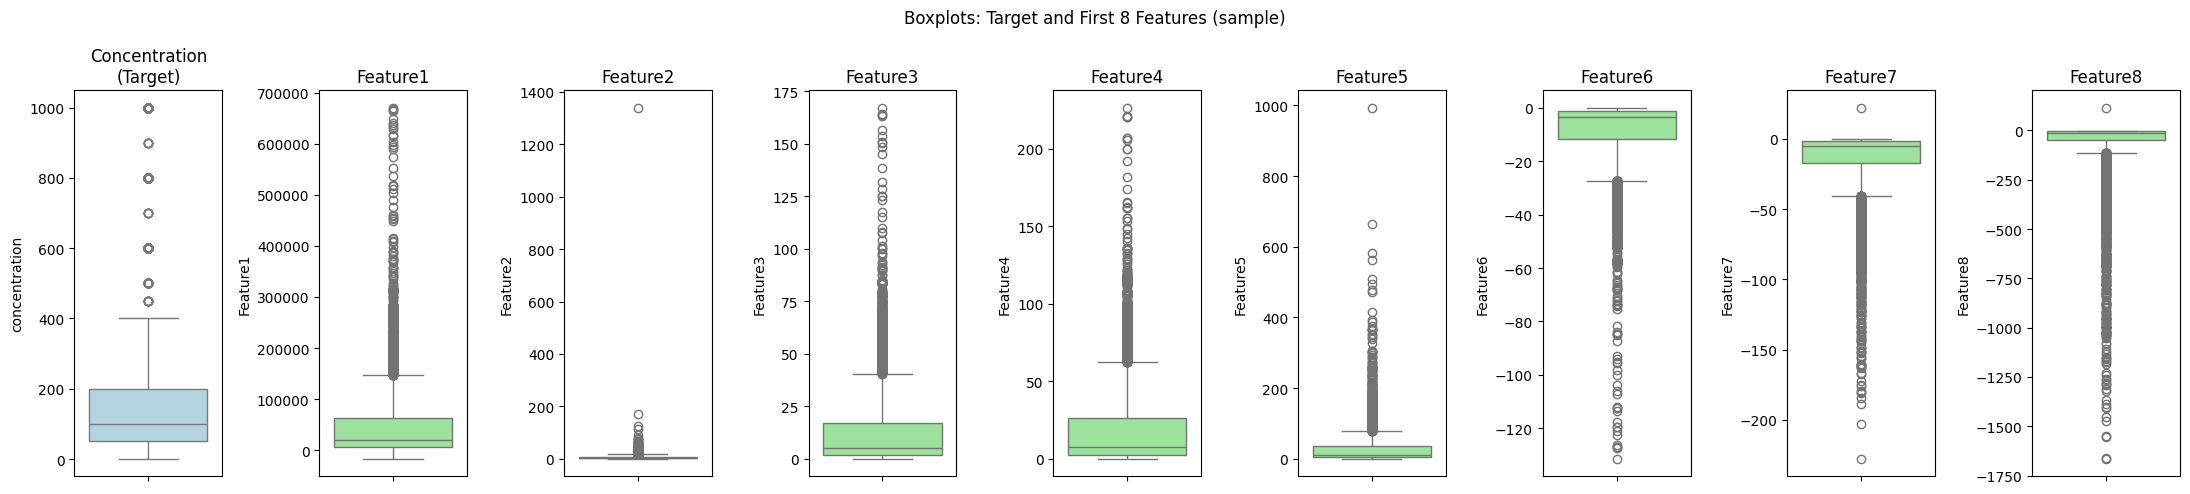

In [54]:
# Boxplots for target + first 8 features as a visual sample
fig, axes = plt.subplots(1, 9, figsize=(22, 5))

sns.boxplot(y=df["concentration"], ax=axes[0], color="lightblue")
axes[0].set_title("Concentration\n(Target)")

for i in range(1, 9):
    sns.boxplot(y=df[f"Feature{i}"], ax=axes[i], color="lightgreen")
    axes[i].set_title(f"Feature{i}")

plt.suptitle("Boxplots: Target and First 8 Features (sample)", fontsize=12)
plt.tight_layout()
plt.show()

In [55]:
# IQR outlier analysis for ALL 128 features
outlier_results = []

for feature in feature_columns:
    Q1  = df[feature].quantile(0.25)
    Q3  = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_outliers = ((df[feature] < lower_bound) | (df[feature] > upper_bound)).sum()
    pct_outliers = (n_outliers / len(df)) * 100

    outlier_results.append({
        "Feature":            feature,
        "Q1":                 round(Q1, 4),
        "Q3":                 round(Q3, 4),
        "IQR":                round(IQR, 4),
        "Lower Bound":        round(lower_bound, 4),
        "Upper Bound":        round(upper_bound, 4),
        "Outlier Count":      int(n_outliers),
        "Outlier Percentage": round(pct_outliers, 2)
    })

outlier_summary = pd.DataFrame(outlier_results)

print("Top 15 features with highest outlier percentage:")
display(
    outlier_summary
    .sort_values(by="Outlier Percentage", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

Top 15 features with highest outlier percentage:


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Feature16,-57.7813,-9.4649,48.3164,-130.2558,63.0096,1862,13.39
1,Feature8,-48.4928,-5.2122,43.2806,-113.4136,59.7086,1767,12.70
2,Feature1,6694.7260,63104.8371,56410.1112,-77920.4408,147720.0039,1418,10.19
3,Feature72,-48.7860,-6.4752,42.3108,-112.2522,56.9909,1380,9.92
4,Feature80,-35.8012,-5.2687,30.5325,-81.5999,40.5300,1355,9.74
5,Feature7,-17.2926,-1.6703,15.6222,-40.7259,21.7630,1295,9.31
6,Feature6,-11.5872,-1.1269,10.4603,-27.2776,14.5635,1283,9.22
7,Feature42,2.0990,3.3201,1.2210,0.2675,5.1516,1260,9.06
8,Feature9,13287.3019,70300.7826,57013.4807,-72232.9192,155821.0036,1225,8.81
9,Feature76,2.6075,17.2306,14.6231,-19.3272,39.1652,1156,8.31


In [56]:
# Full outlier summary for all 128 features
print("Full outlier summary (all 128 features):")
display(outlier_summary)

Full outlier summary (all 128 features):


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Feature1,6694.7260,63104.8371,56410.1112,-77920.4408,147720.0039,1418,10.19
1,Feature2,2.2848,8.4006,6.1158,-6.8888,17.5743,895,6.43
2,Feature3,1.6334,17.1892,15.5558,-21.7004,40.5229,1134,8.15
3,Feature4,2.3868,26.4111,24.0243,-33.6496,62.4475,976,7.02
4,Feature5,4.9680,34.8432,29.8752,-39.8449,79.6561,1004,7.22
5,Feature6,-11.5872,-1.1269,10.4603,-27.2776,14.5635,1283,9.22
6,Feature7,-17.2926,-1.6703,15.6222,-40.7259,21.7630,1295,9.31
7,Feature8,-48.4928,-5.2122,43.2806,-113.4136,59.7086,1767,12.70
8,Feature9,13287.3019,70300.7826,57013.4807,-72232.9192,155821.0036,1225,8.81
9,Feature10,2.7767,8.6085,5.8318,-5.9711,17.3563,694,4.99


**Observation:** Several features have 10–30% of values flagged as outliers by the IQR rule.
This is expected for sensor data — at higher concentrations, sensor response curves are non-linear
and can produce values well outside the interquartile range for low-concentration measurements.
We retain all samples; tree-based and non-linear models are naturally robust to these values.

### Target Distribution (Concentration)

========== TARGET DISTRIBUTION ==========



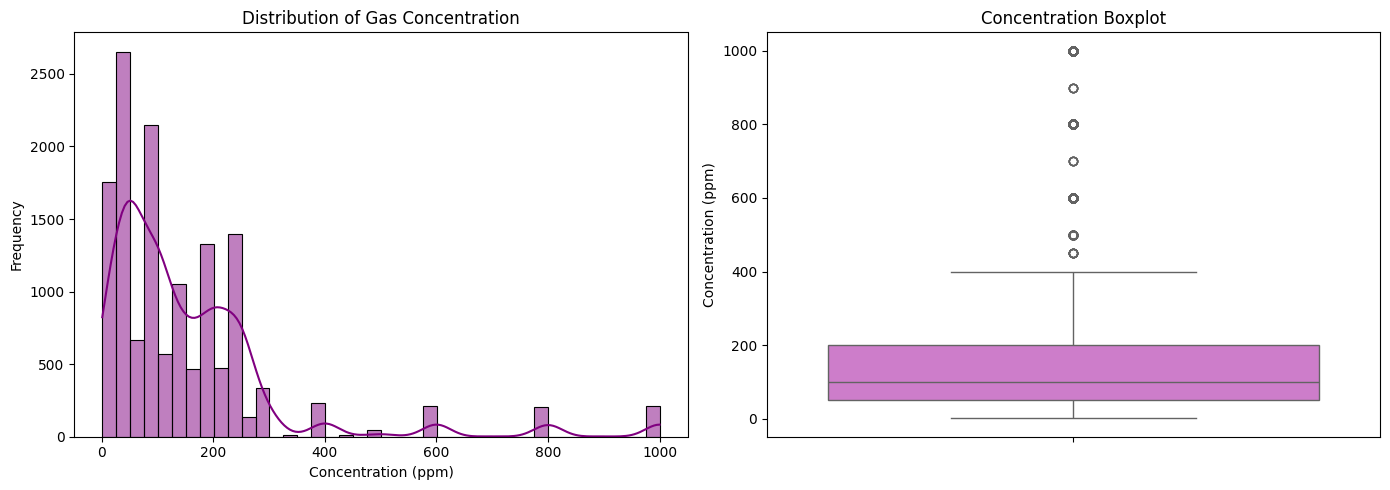

In [57]:
print("========== TARGET DISTRIBUTION ==========\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df["concentration"], bins=40, kde=True, color="purple", ax=axes[0])
axes[0].set_xlabel("Concentration (ppm)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Gas Concentration")

# Box plot
sns.boxplot(y=df["concentration"], color="orchid", ax=axes[1])
axes[1].set_ylabel("Concentration (ppm)")
axes[1].set_title("Concentration Boxplot")

plt.tight_layout()
plt.show()

**Observation:** The concentration distribution is strongly **right-skewed**. The majority of measurements
are at lower concentrations (50–200 ppm), but values go up to 1,000 ppm. This imbalance means linear
models may underperform in the high-concentration tail, while tree-based models can handle this better
by splitting the feature space at different thresholds.

### Feature Distributions — All 128 Sensor Features

We plot histograms for **all 128 features** in a 16 × 8 grid to understand
the distribution shape, range, and skewness of every sensor-derived measurement.

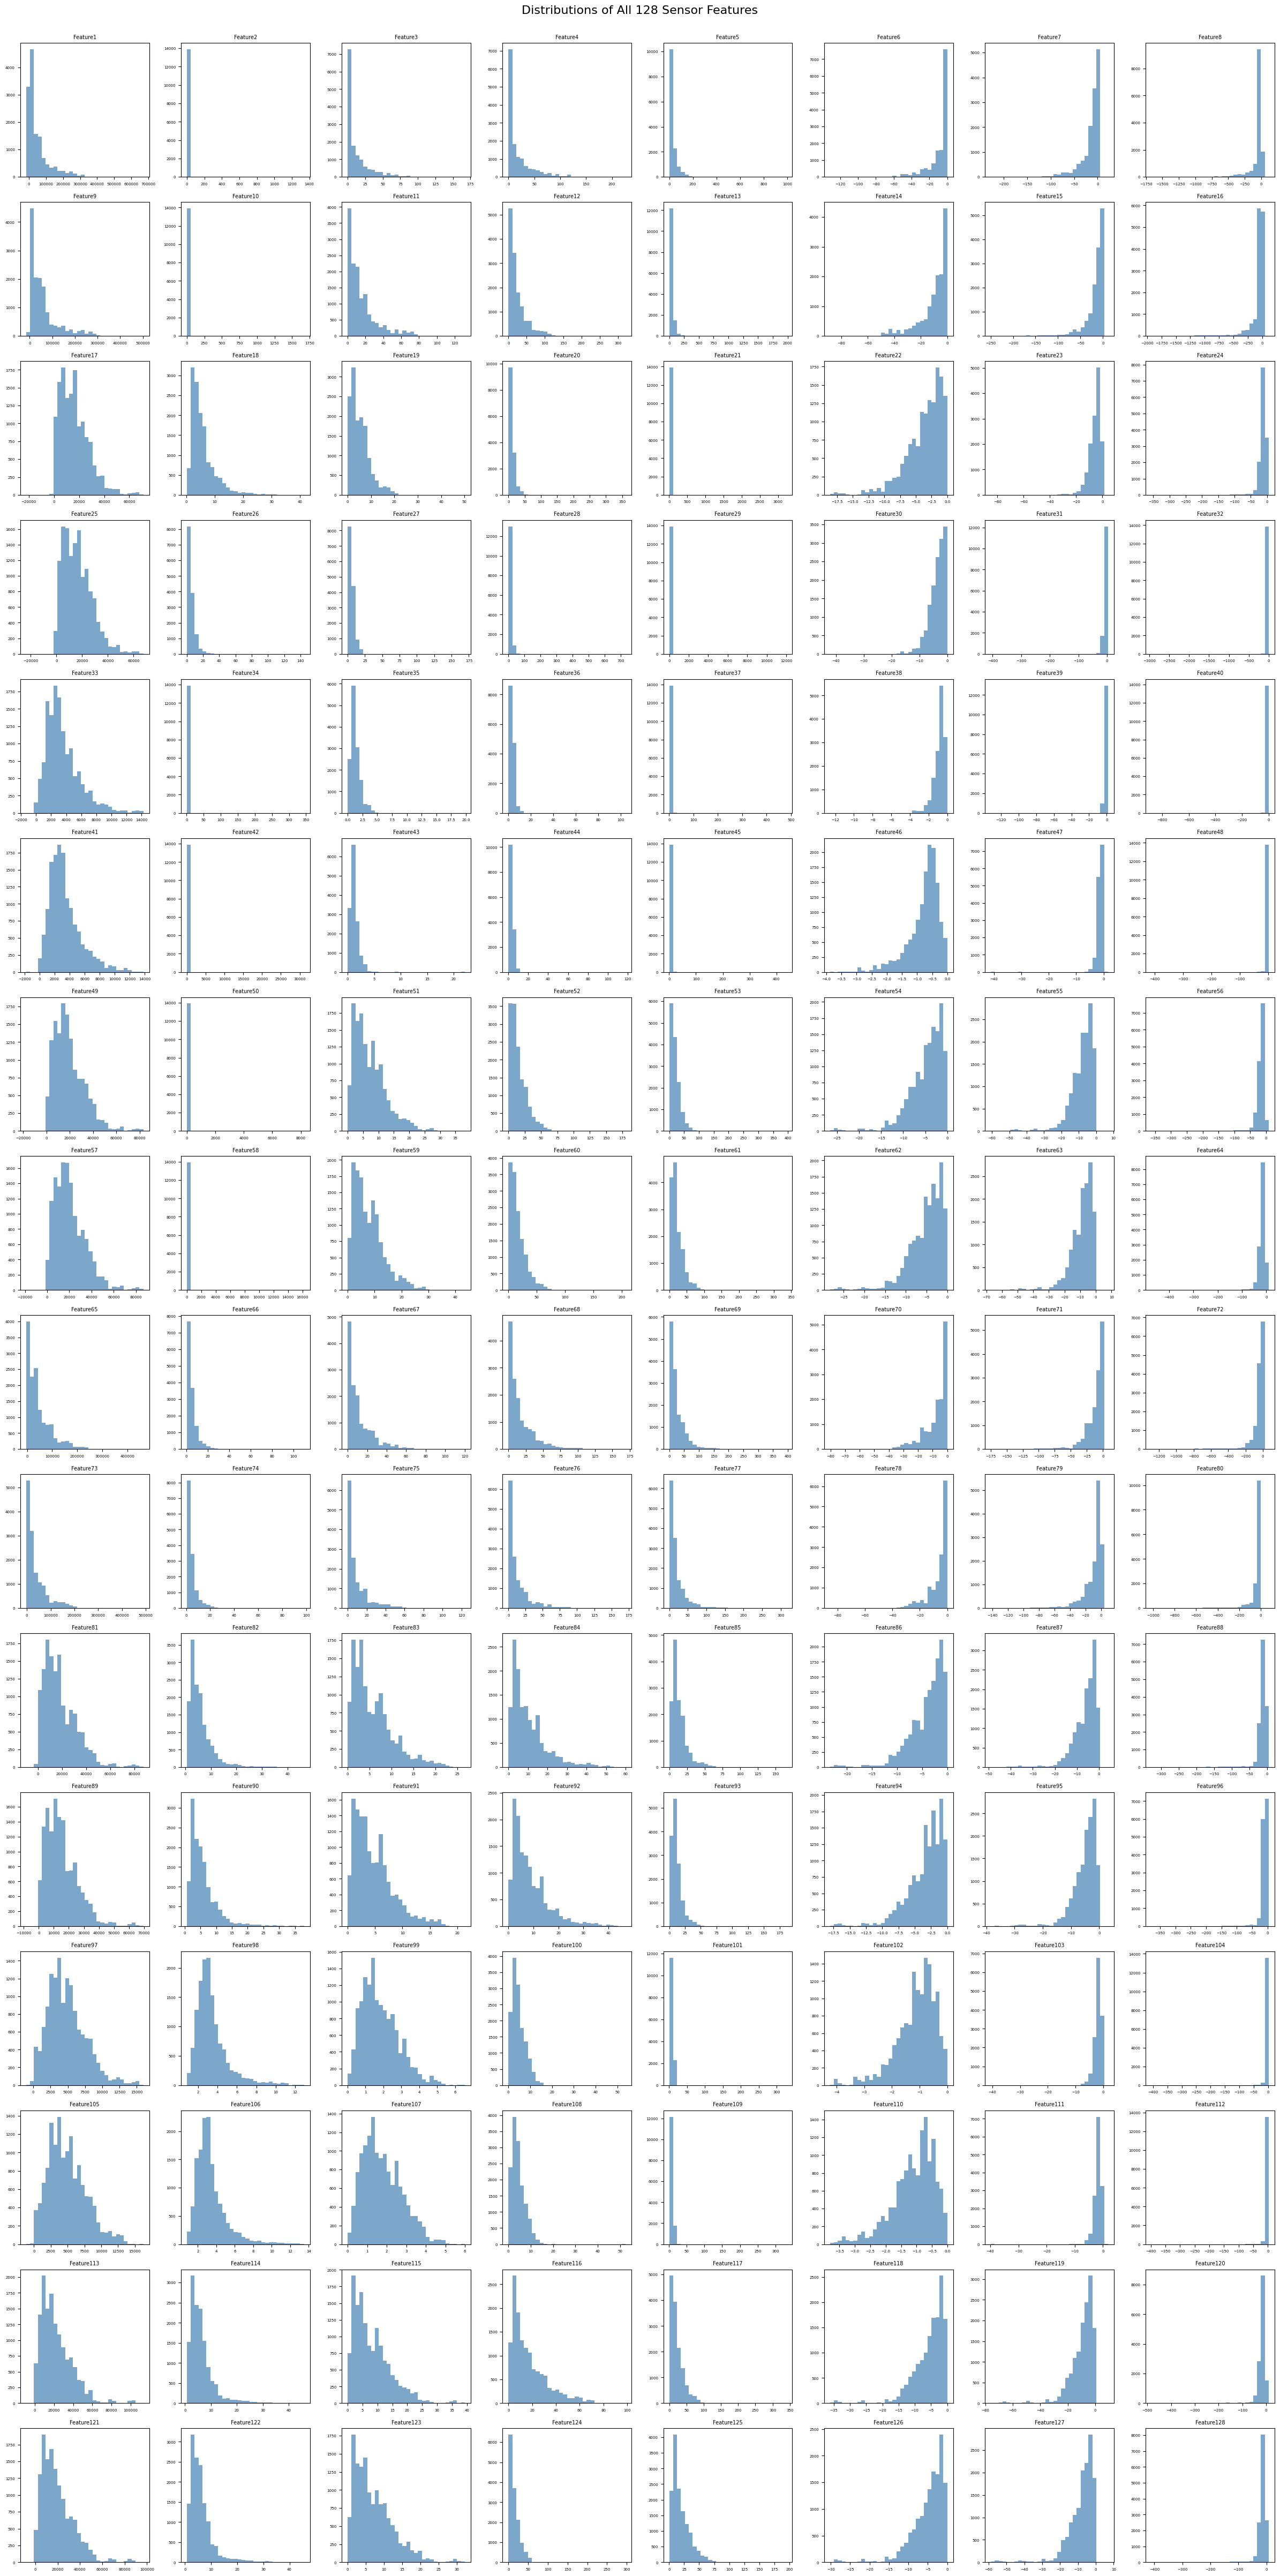

In [58]:
# Grid of histograms for all 128 features
n_cols = 8
n_rows = 16  # 128 / 8

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 48))
axes = axes.flatten()

for i, feature in enumerate(feature_columns):
    axes[i].hist(df[feature], bins=30, color="steelblue", alpha=0.7, edgecolor="none")
    axes[i].set_title(feature, fontsize=7)
    axes[i].tick_params(labelsize=5)

plt.suptitle("Distributions of All 128 Sensor Features", fontsize=16, y=1.001)
plt.tight_layout()
plt.show()

**Observation:** Feature distributions vary significantly across the 128 columns:
- Some features (e.g., Feature1) show a wide, right-skewed distribution with occasional very large values.
- Many EMA-based features (approx. Features 3–6, 11–14, …) are symmetric and near-zero.
- Features derived from steady-state sensor response (DR) tend to have much larger magnitude and variance.
This heterogeneity makes **StandardScaler** essential before training any model that is sensitive to feature scale.

### Correlation of All Features with the Target (Concentration)

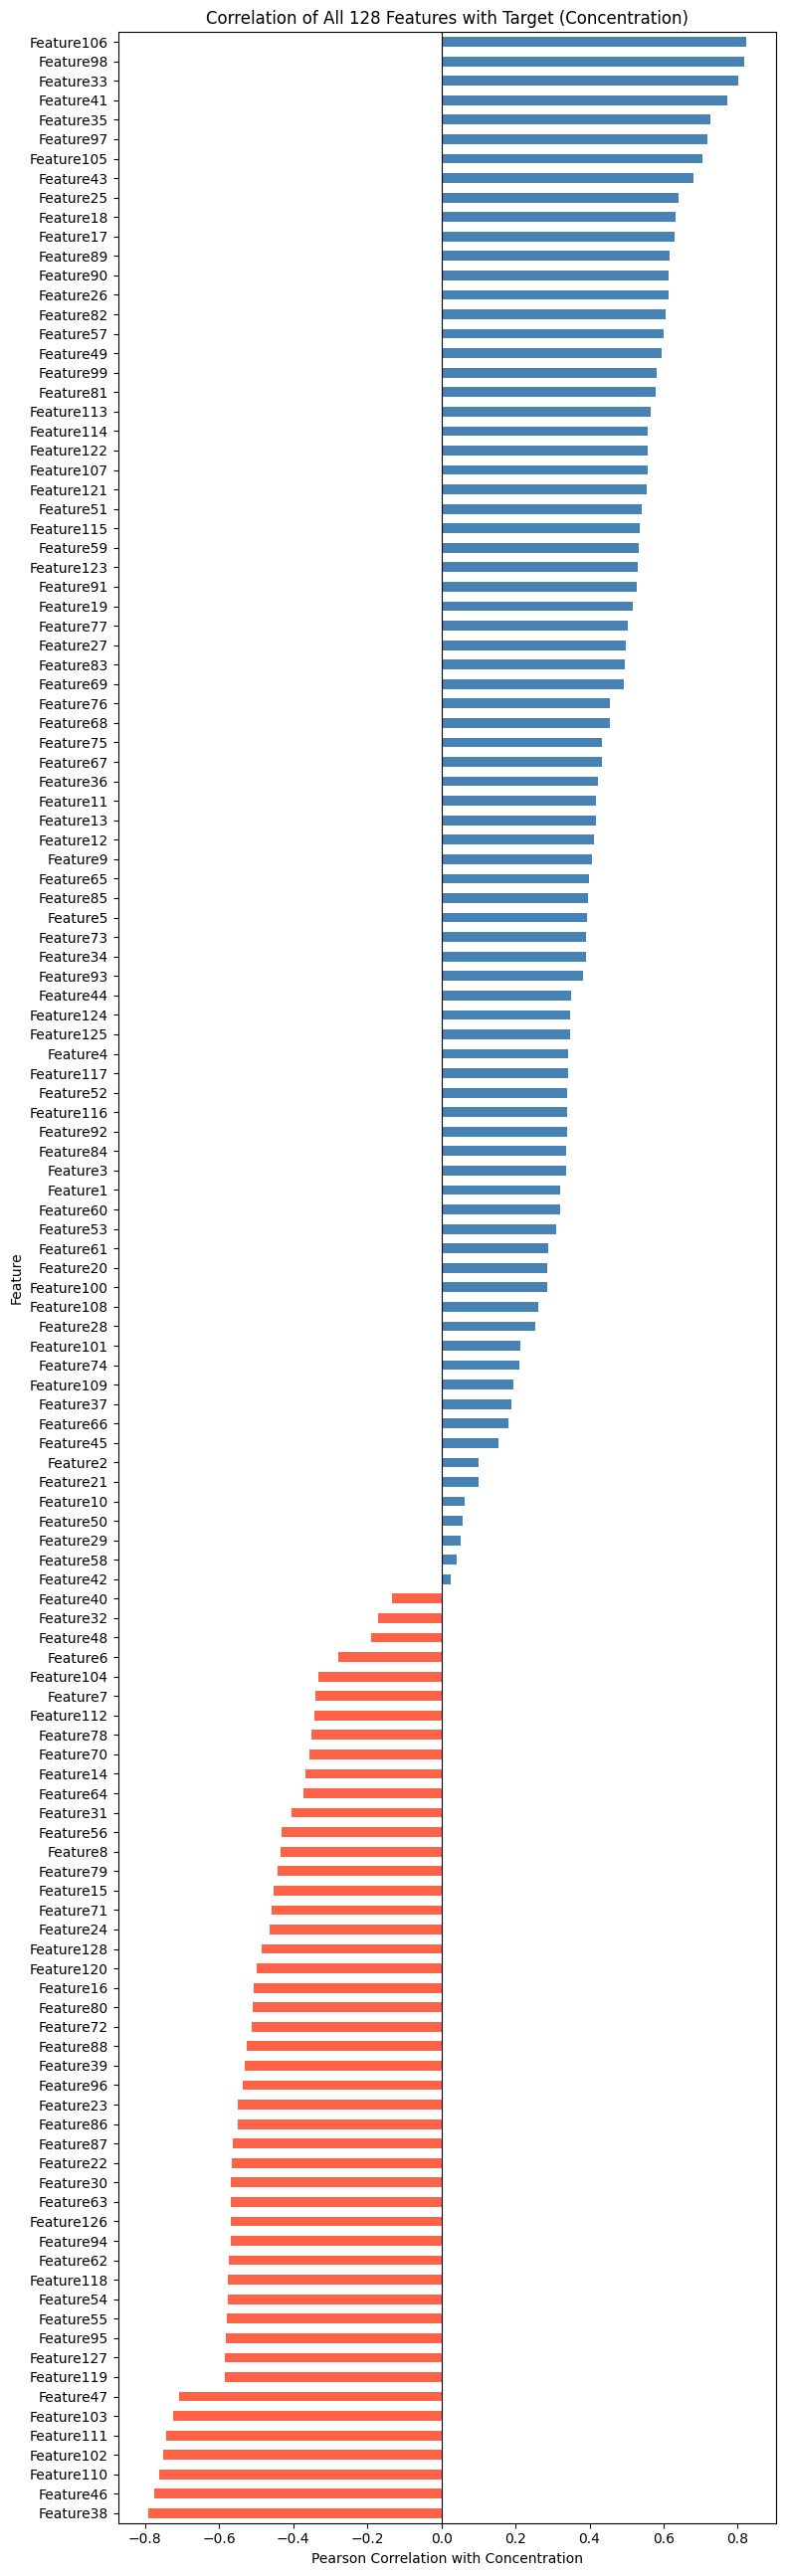

Top 5 positively correlated features:
Feature106    0.822749
Feature98     0.818607
Feature33     0.800839
Feature41     0.772820
Feature35     0.725133
dtype: float64

Top 5 negatively correlated features:
Feature38    -0.792276
Feature46    -0.774427
Feature110   -0.760488
Feature102   -0.751543
Feature111   -0.743521
dtype: float64


In [59]:
# Pearson correlation of all 128 features with the target variable
target_corr = df[feature_columns].corrwith(df["concentration"]).sort_values()

colors = ["tomato" if x < 0 else "steelblue" for x in target_corr]

plt.figure(figsize=(8, 26))
target_corr.plot(kind="barh", color=colors)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("Pearson Correlation with Concentration")
plt.ylabel("Feature")
plt.title("Correlation of All 128 Features with Target (Concentration)")
plt.tight_layout()
plt.show()

# Print top 10 most positively and negatively correlated
print("Top 5 positively correlated features:")
print(target_corr.nlargest(5))
print("\nTop 5 negatively correlated features:")
print(target_corr.nsmallest(5))

**Observation:** Most features show **moderate positive or negative correlation** with concentration.
Features derived from the DR (direct sensor response) tend to have higher absolute correlation,
as they capture the primary signal amplitude. EMA-based features tend to show weaker correlation
individually, though they contribute useful dynamic information. No single feature dominates,
suggesting an ensemble or regularised approach will work better than a simple linear model.

### Correlation Heatmap

Two views:
1. Full 128×128 heatmap (no annotations — too dense at this size) to see overall block structure.
2. Zoomed heatmap of the 15 features with highest absolute correlation with concentration.

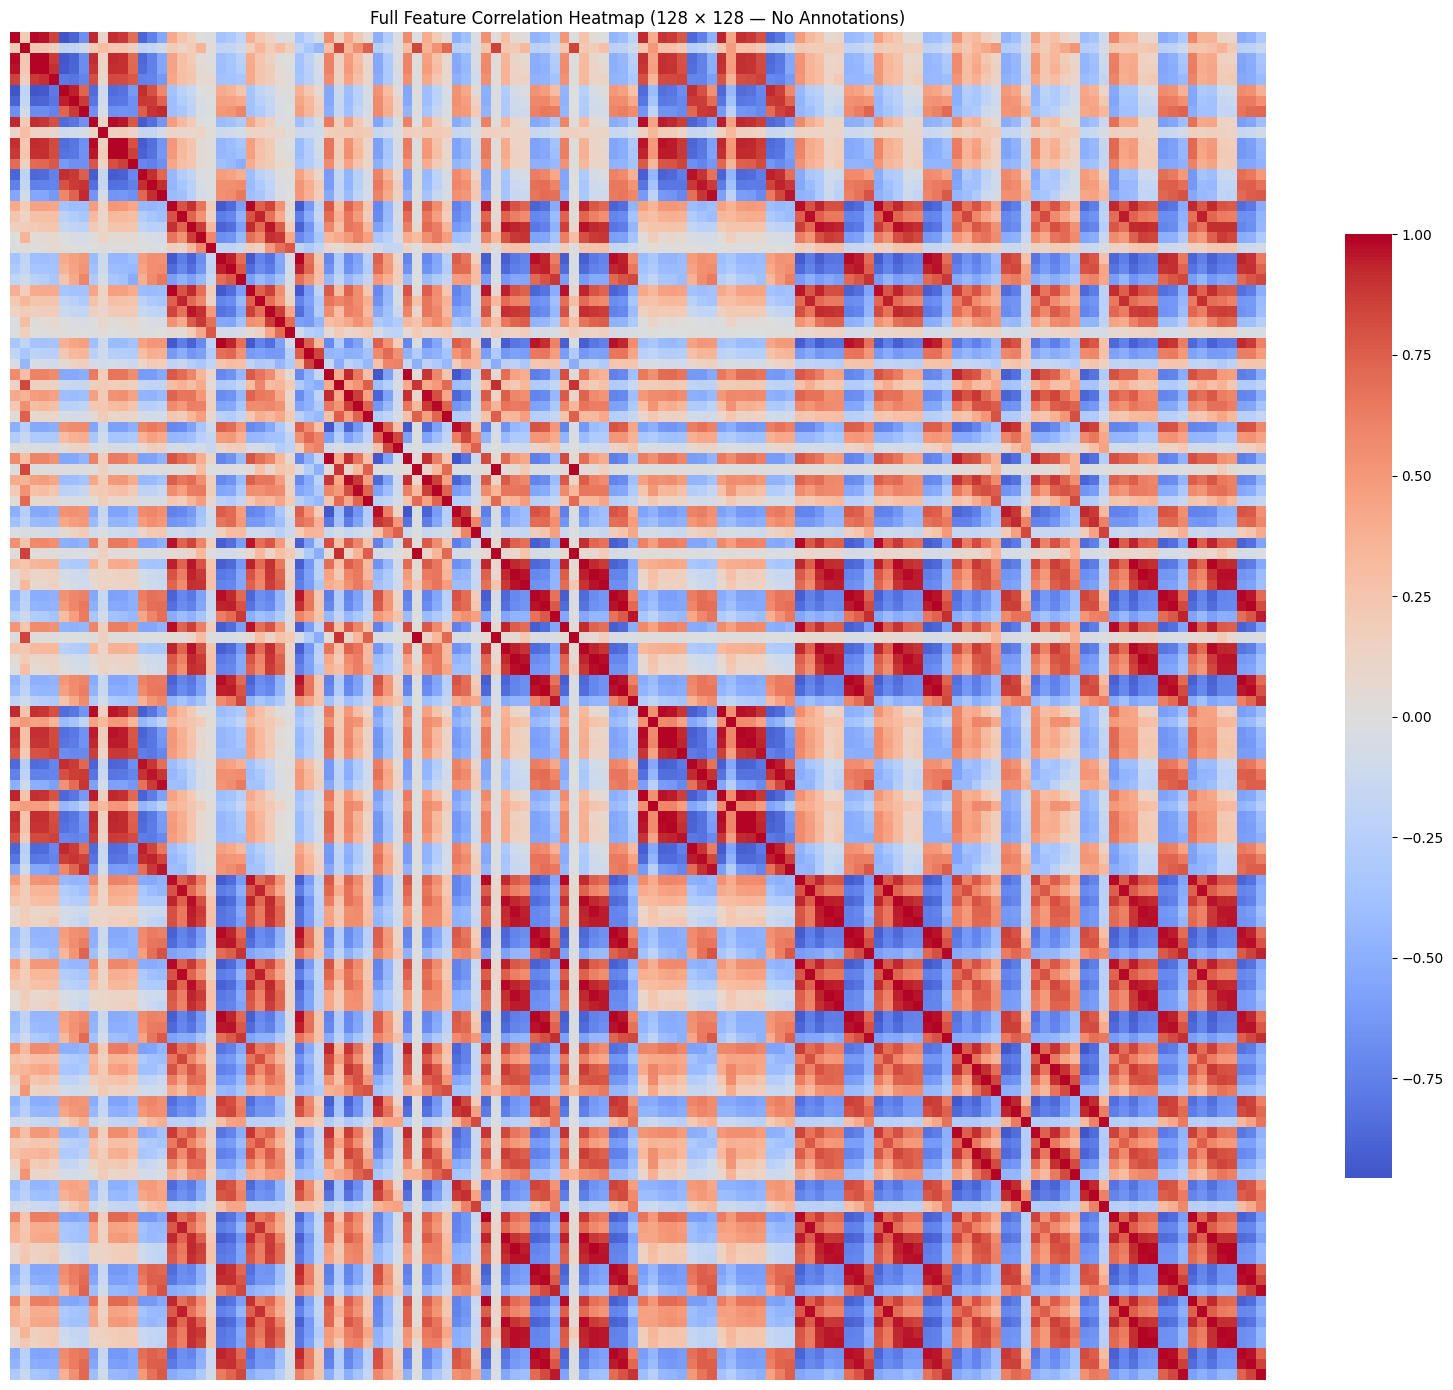

In [60]:
# Full 128×128 correlation heatmap (no annotations)
corr_matrix_full = df[feature_columns].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix_full,
    cmap="coolwarm",
    center=0,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"shrink": 0.7}
)
plt.title("Full Feature Correlation Heatmap (128 × 128 — No Annotations)")
plt.tight_layout()
plt.show()

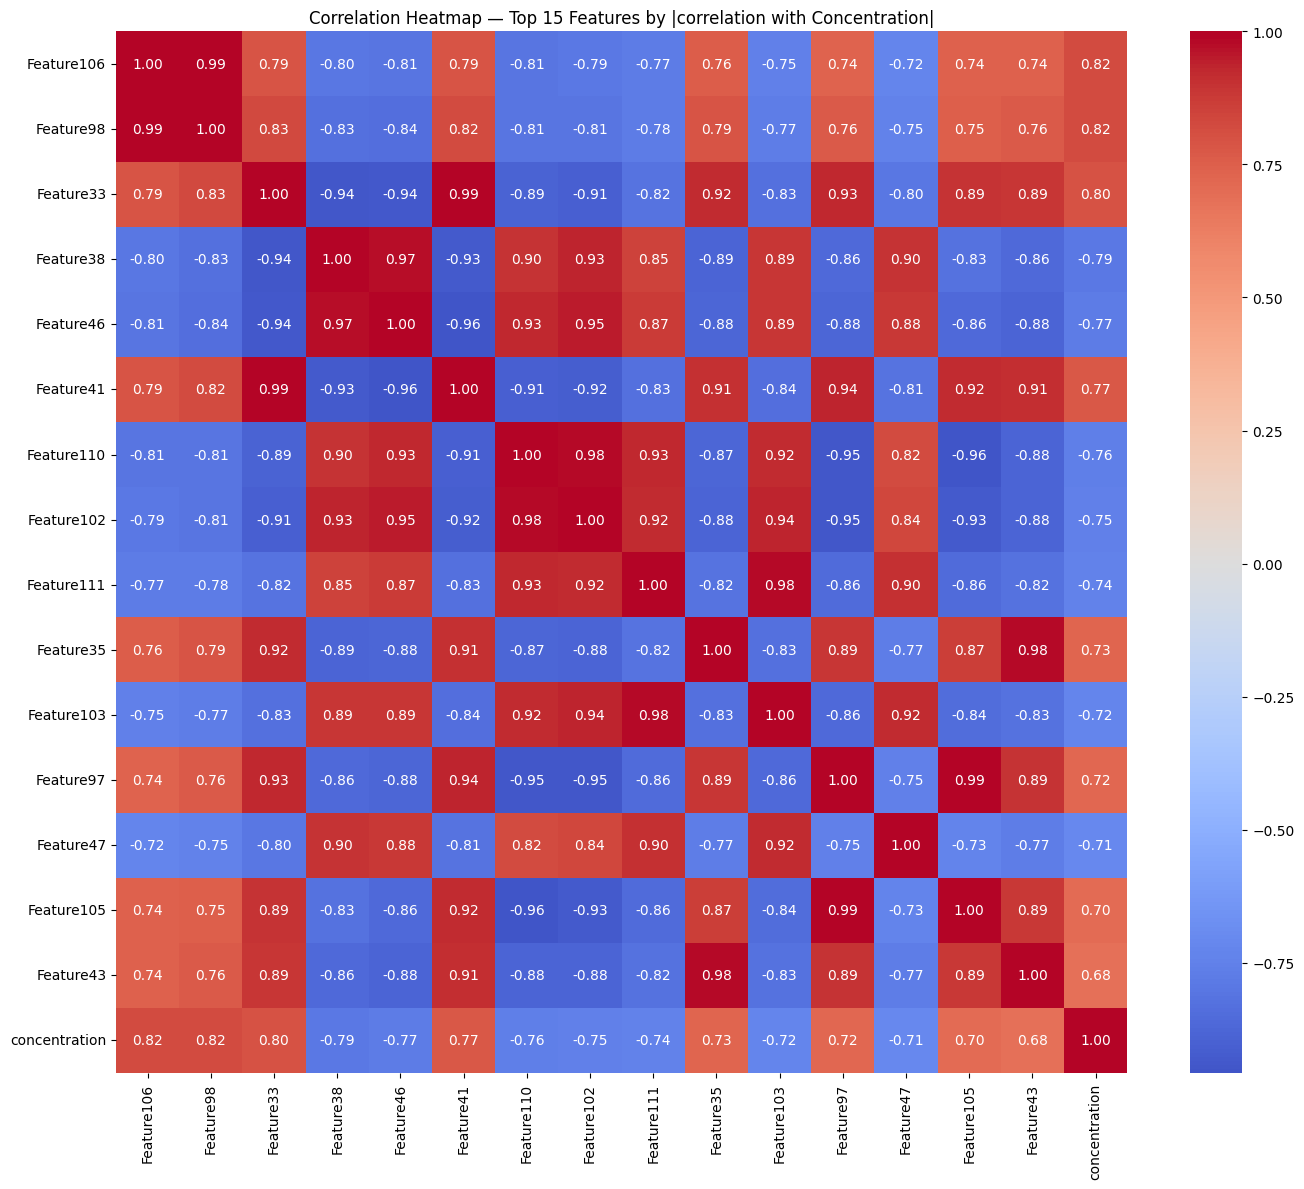

In [61]:
# Annotated heatmap: top 15 features by absolute correlation with concentration
top15_features = target_corr.abs().nlargest(15).index.tolist()
subset_corr = df[top15_features + ["concentration"]].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    subset_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap — Top 15 Features by |correlation with Concentration|")
plt.tight_layout()
plt.show()

**Observation:** The full 128×128 heatmap reveals a strong **block structure** — features from the
same sensor (every group of 8) are highly correlated with each other. This multi-collinearity is
expected and justifies using **Ridge/Lasso/ElasticNet** (which handle correlated features via regularisation)
alongside tree-based models. The zoomed heatmap shows that the top-15 most informative features
also show inter-feature correlations around 0.5–0.9, further confirming the redundancy in raw features.

### Feature-Target Scatter Plots

Scatter plots of the **4 features most correlated with concentration** (by absolute Pearson correlation).
These give the clearest visual view of the feature-concentration relationship.

Top 4 features for scatter plots: ['Feature106', 'Feature98', 'Feature33', 'Feature38']


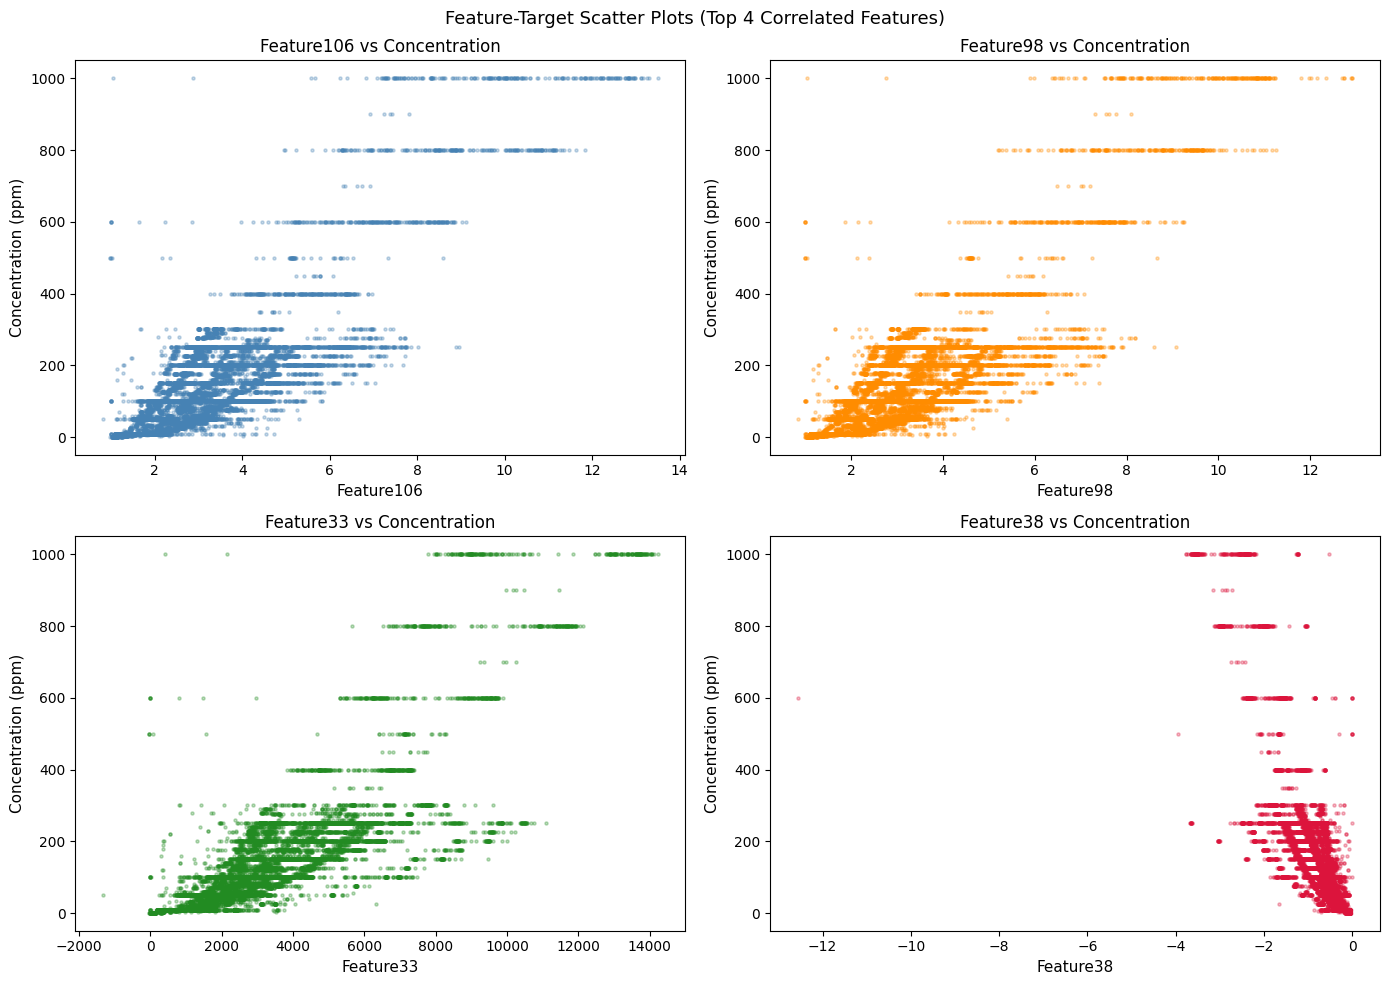

In [62]:
# Top 4 features by absolute correlation with target
top4_features = target_corr.abs().nlargest(4).index.tolist()
print("Top 4 features for scatter plots:", top4_features)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

palette = ["steelblue", "darkorange", "forestgreen", "crimson"]

for i, feature in enumerate(top4_features):
    axes[i].scatter(
        df[feature], df["concentration"],
        alpha=0.3, s=5, color=palette[i]
    )
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].set_ylabel("Concentration (ppm)", fontsize=11)
    axes[i].set_title(f"{feature} vs Concentration")

plt.suptitle("Feature-Target Scatter Plots (Top 4 Correlated Features)", fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** The scatter plots reveal a **non-linear, fan-shaped** relationship between the top
sensor features and concentration. At low concentrations the sensor readings cluster tightly,
but at higher concentrations the spread increases substantially. This heteroscedasticity suggests
that linear models may struggle, while tree-based and kernel-based models (RF, GBR, SVR) are
better suited to capture the non-linear signal.

## 3. Preprocessing and Feature Engineering

### Engineered Feature: SensorMean

We create one engineered feature: **SensorMean** — the row-wise mean across all 128 sensor readings.

**What it represents:**
SensorMean captures the *average activation level* across all 16 sensors (each contributing 8 features).
It is a single scalar that summarises the overall sensor array response for each measurement.

**Why it may improve model performance:**
Higher gas concentrations tend to produce stronger overall sensor responses. A global average
of all sensor readings acts as a concentration proxy — providing the model with a compact,
noise-reduced summary of the full feature set alongside the individual features.

**No target leakage:**
SensorMean is computed purely from Feature1–Feature128 (the input features).
It does not use `concentration`, `gas_class`, or any target-derived information.

In [63]:
# Create engineered feature: row-wise mean of all 128 sensor features
df["SensorMean"] = df[feature_columns].mean(axis=1)

print("SensorMean descriptive statistics:")
print(df["SensorMean"].describe())

# Check its correlation with the target
corr_val = df["SensorMean"].corr(df["concentration"])
print(f"\nCorrelation of SensorMean with concentration: {corr_val:.4f}")

SensorMean descriptive statistics:
count    13910.000000
mean      2791.463332
std       2390.996869
min      -1285.267343
25%       1252.998561
50%       2088.373243
75%       3483.814452
max      20050.684059
Name: SensorMean, dtype: float64

Correlation of SensorMean with concentration: 0.5122


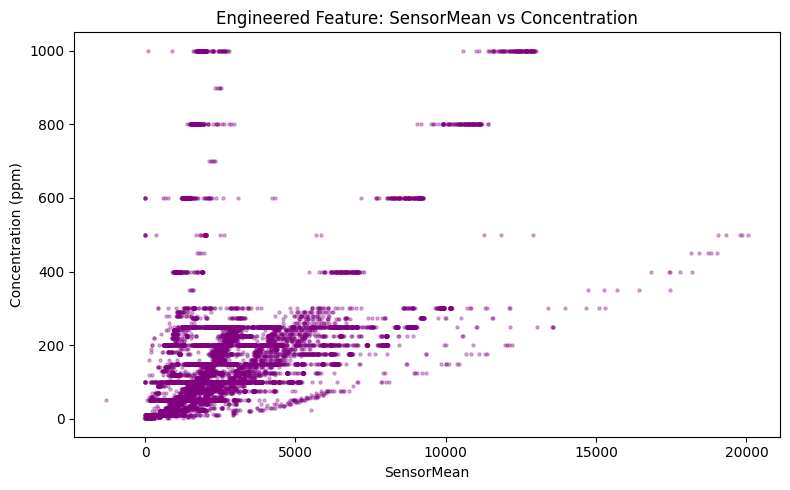

In [64]:
# Scatter: SensorMean vs Concentration
plt.figure(figsize=(8, 5))
plt.scatter(df["SensorMean"], df["concentration"], alpha=0.3, s=5, color="purple")
plt.xlabel("SensorMean")
plt.ylabel("Concentration (ppm)")
plt.title("Engineered Feature: SensorMean vs Concentration")
plt.tight_layout()
plt.show()

In [65]:
# Final feature set: 128 original sensor features + SensorMean
all_feature_columns = feature_columns + ["SensorMean"]

X = df[all_feature_columns].copy()
y = df["concentration"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures used:", len(all_feature_columns))
print("  - 128 original sensor features")
print("  - 1 engineered feature (SensorMean)")

X shape: (13910, 129)
y shape: (13910,)

Features used: 129
  - 128 original sensor features
  - 1 engineered feature (SensorMean)


## 4. Train/Test Split and Scaling

**Split ratio:** 80% train / 20% test with `random_state=42` for reproducibility.

**On stratification:** Stratified splitting applies to classification tasks where the target
is categorical. Here the target (`concentration`) is a **continuous** variable, so
`stratify=y` is not applicable. We use a standard random split.

**Scaling:** `StandardScaler` is fitted **only on the training data** and then applied
to transform both train and test sets. Fitting on the full dataset would leak test-set
distribution information into training — a data leakage error.

In [66]:
# 80/20 train-test split — no stratify (continuous target)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Training set:  {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")
print(f"Features:      {X_train.shape[1]}")

Training set:  11128 samples
Test set:      2782 samples
Features:      129


In [67]:
# StandardScaler — fit on training data only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape: ", X_test_scaled.shape)

Scaling complete.
X_train_scaled shape: (11128, 129)
X_test_scaled shape:  (2782, 129)


## 5. Regression — Ten Models

All ten required regression algorithms are trained. Where specified by the rubric, hyperparameter tuning
(e.g., alpha, l1_ratio, max_depth, k) is applied directly here using cross-validation (CV). 

*Note: Extensive tuning for Random Forest (n_estimators) and Gradient Boosting (learning_rate)
is performed in Section 8 as part of the overall top-2 model tuning requirement.*

### Model 1 — Linear Regression

Baseline model. We fit it and interpret the coefficients.

In [68]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_preds = linear_model.predict(X_test_scaled)

# Interpret coefficients
coef_series = pd.Series(linear_model.coef_, index=all_feature_columns)
print('Top 5 Positive Coefficients:')
print(coef_series.nlargest(5))
print('\nTop 5 Negative Coefficients:')
print(coef_series.nsmallest(5))
print('\nLinear Regression — trained.')

Top 5 Positive Coefficients:
Feature42    4112.026962
Feature91     584.215529
Feature49     415.235405
Feature97     367.911192
Feature50     324.069872
dtype: float64

Top 5 Negative Coefficients:
Feature58    -4365.228582
Feature83     -636.267432
Feature51     -511.757247
Feature118    -394.013563
Feature92     -355.769927
dtype: float64

Linear Regression — trained.


**Interpretation:** The coefficients show which features most strongly drive the prediction up (positive) or down (negative) in a strictly linear relationship. Features with the largest absolute coefficients have the biggest impact, assuming all features are on the same standard scale.

### Model 2 — Ridge Regression

L2 regularisation. We tune `alpha` using `RidgeCV` to find the optimal penalty for multi-collinearity.

In [69]:
from sklearn.linear_model import RidgeCV

ridge_model = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0], cv=5)
ridge_model.fit(X_train_scaled, y_train)
ridge_preds = ridge_model.predict(X_test_scaled)

print(f'Ridge Regression — trained. Best alpha: {ridge_model.alpha_}')

Ridge Regression — trained. Best alpha: 100.0


### Model 3 — Lasso Regression

L1 regularisation. We observe feature sparsity (coefficients driven to exactly zero).

In [70]:
lasso_model = Lasso(alpha=0.1, random_state=RANDOM_STATE)
lasso_model.fit(X_train_scaled, y_train)
lasso_preds = lasso_model.predict(X_test_scaled)

n_zero = (lasso_model.coef_ == 0).sum()
total_features = len(lasso_model.coef_)
print(f'Lasso Regression — trained.')
print(f'Features zeroed out (sparsity): {n_zero} / {total_features} ({n_zero/total_features*100:.1f}%)')

Lasso Regression — trained.
Features zeroed out (sparsity): 41 / 129 (31.8%)


### Model 4 — ElasticNet Regression

Combined L1+L2. We tune `l1_ratio` using `ElasticNetCV`.

In [71]:
from sklearn.linear_model import ElasticNetCV

elastic_model = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 1.0], cv=5, random_state=RANDOM_STATE)
elastic_model.fit(X_train_scaled, y_train)
elastic_preds = elastic_model.predict(X_test_scaled)

print(f'ElasticNet Regression — trained. Best l1_ratio: {elastic_model.l1_ratio_}')

ElasticNet Regression — trained. Best l1_ratio: 1.0


### Model 5 — Polynomial Regression

We compare degree=1 (Linear) and degree=2 (Polynomial) on the top 10 features by variance.

In [72]:
# Top 10 features
train_vars = pd.Series(X_train_scaled.var(axis=0), index=all_feature_columns)
top10_indices = [all_feature_columns.index(f) for f in train_vars.nlargest(10).index]
X_train_top10 = X_train_scaled[:, top10_indices]
X_test_top10  = X_test_scaled[:, top10_indices]

# Degree 1
lr_deg1 = LinearRegression().fit(X_train_top10, y_train)
r2_deg1 = r2_score(y_test, lr_deg1.predict(X_test_top10))

# Degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_top10)
X_test_poly  = poly.transform(X_test_top10)
polynomial_model = LinearRegression().fit(X_train_poly, y_train)
polynomial_preds = polynomial_model.predict(X_test_poly)
r2_deg2 = r2_score(y_test, polynomial_preds)

print(f'Degree 1 R²: {r2_deg1:.4f}')
print(f'Degree 2 R²: {r2_deg2:.4f}')
print('Polynomial Regression (degree 2) — trained and selected.')

Degree 1 R²: 0.3765
Degree 2 R²: -38.9171
Polynomial Regression (degree 2) — trained and selected.


### Model 6 — Decision Tree Regressor

We tune `max_depth` and display feature importance.

In [73]:
dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), 
                       param_grid={"max_depth": [5, 10, 20, None]}, cv=3)
dt_grid.fit(X_train_scaled, y_train)
decision_tree_model = dt_grid.best_estimator_
decision_tree_preds = decision_tree_model.predict(X_test_scaled)

print(f'Decision Tree — trained. Best max_depth: {decision_tree_model.max_depth}')

dt_importances = pd.Series(decision_tree_model.feature_importances_, index=all_feature_columns)
print('\nTop 5 Feature Importances:')
print(dt_importances.nlargest(5))

Decision Tree — trained. Best max_depth: 20

Top 5 Feature Importances:
Feature106    0.538173
Feature41     0.146943
Feature111    0.050318
Feature69     0.040923
Feature127    0.024970
dtype: float64


### Model 7 — Random Forest Regressor

Ensemble baseline. Note: Extensive tuning of `n_estimators` is reserved for Section 8.

In [74]:
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
random_forest_model.fit(X_train_scaled, y_train)
random_forest_preds = random_forest_model.predict(X_test_scaled)
print('Random Forest Regressor — baseline trained.')

Random Forest Regressor — baseline trained.


### Model 8 — Gradient Boosting Regressor

Note: Extensive tuning of `learning_rate` is reserved for Section 8.

In [75]:
gradient_boosting_model = GradientBoostingRegressor(learning_rate=0.1, n_estimators=100, random_state=RANDOM_STATE)
gradient_boosting_model.fit(X_train_scaled, y_train)
gradient_boosting_preds = gradient_boosting_model.predict(X_test_scaled)
print('Gradient Boosting Regressor — baseline trained.')

Gradient Boosting Regressor — baseline trained.


### Model 9 — Support Vector Regressor (SVR)

Features are already scaled. We tune `C` and `kernel` using a focused GridSearchCV.

In [76]:
svr_grid = GridSearchCV(SVR(), param_grid={"C": [0.1, 1.0], "kernel": ["linear", "rbf"]}, cv=3, n_jobs=-1)
svr_grid.fit(X_train_scaled, y_train)
svr_model = svr_grid.best_estimator_
svr_preds = svr_model.predict(X_test_scaled)
print(f'SVR — trained. Best parameters: {svr_grid.best_params_}')

SVR — trained. Best parameters: {'C': 0.1, 'kernel': 'linear'}


### Model 10 — K-Nearest Neighbors Regressor

We tune `k` (n_neighbors) using GridSearchCV.

In [77]:
knn_grid = GridSearchCV(KNeighborsRegressor(), param_grid={"n_neighbors": [3, 5, 7, 9]}, cv=3, n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
knn_model = knn_grid.best_estimator_
knn_preds = knn_model.predict(X_test_scaled)
print(f'KNN — trained. Best k: {knn_model.n_neighbors}')

KNN — trained. Best k: 3


**Impact of scaling on KNN:** KNN relies on Euclidean distance. Because our unscaled features have drastically different ranges (some ±50, some >1000), the large-magnitude features would completely dominate the distance calculation. By using `StandardScaler` first, all features contribute proportionately, which is critical for KNN to perform reasonably well.

## 6. Metrics and Regression Visualizations

Evaluation metrics — all mandatory per rubric:
- **R²** (coefficient of determination)
- **RMSE** (root mean squared error)
- **MAE** (mean absolute error)
- **5-fold cross-validated R²** for the two best models (reported in Section 9)

In [78]:
def evaluate_regressor(model_name, y_true, y_pred):
    """Compute R², RMSE, and MAE for one regression model."""
    r2   = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae  = mean_absolute_error(y_true, y_pred)
    return {
        "Model": model_name,
        "R²":    round(r2,   4),
        "RMSE":  round(rmse, 4),
        "MAE":   round(mae,  4)
    }

print("evaluate_regressor() defined.")

evaluate_regressor() defined.


In [79]:
# Evaluate all 10 models on the same test set
all_results = [
    evaluate_regressor("Linear Regression",     y_test, linear_preds),
    evaluate_regressor("Ridge Regression",      y_test, ridge_preds),
    evaluate_regressor("Lasso Regression",      y_test, lasso_preds),
    evaluate_regressor("ElasticNet Regression", y_test, elastic_preds),
    evaluate_regressor("Polynomial Regression", y_test, polynomial_preds),
    evaluate_regressor("Decision Tree",         y_test, decision_tree_preds),
    evaluate_regressor("Random Forest",         y_test, random_forest_preds),
    evaluate_regressor("Gradient Boosting",     y_test, gradient_boosting_preds),
    evaluate_regressor("SVR",                   y_test, svr_preds),
    evaluate_regressor("KNN",                   y_test, knn_preds),
]

results_df = pd.DataFrame(all_results)

print("Metrics for all 10 models (test set):")
display(results_df)

Metrics for all 10 models (test set):


,Model,R²,RMSE,MAE
0,Linear Regression,0.8192,73.0633,27.4257
1,Ridge Regression,0.9020,53.7906,32.0707
2,Lasso Regression,0.8759,60.5331,30.4398
3,ElasticNet Regression,0.8583,64.6823,35.9070
4,Polynomial Regression,-38.9171,1085.5221,86.6865
5,Decision Tree,0.9458,40.0041,8.8588
6,Random Forest,0.9650,32.1499,8.0571
7,Gradient Boosting,0.9467,39.6589,20.7150
8,SVR,0.8398,68.7731,33.8427
9,KNN,0.9644,32.4200,5.8344


In [80]:
# Identify best model by R²
best_idx   = results_df["R²"].idxmax()
best_row   = results_df.loc[best_idx]
best_model_name = best_row["Model"]

print("Best model on test set:")
print(best_row.to_string())

Best model on test set:
Model    Random Forest
R²               0.965
RMSE           32.1499
MAE             8.0571


In [81]:
# Map model name → its test predictions
pred_map = {
    "Linear Regression":     linear_preds,
    "Ridge Regression":      ridge_preds,
    "Lasso Regression":      lasso_preds,
    "ElasticNet Regression": elastic_preds,
    "Polynomial Regression": polynomial_preds,
    "Decision Tree":         decision_tree_preds,
    "Random Forest":         random_forest_preds,
    "Gradient Boosting":     gradient_boosting_preds,
    "SVR":                   svr_preds,
    "KNN":                   knn_preds,
}

best_preds = pred_map[best_model_name]
print(f"Predictions stored for: {best_model_name}")

Predictions stored for: Random Forest


### Visualisation 1 — Predicted vs Actual (Best Model)

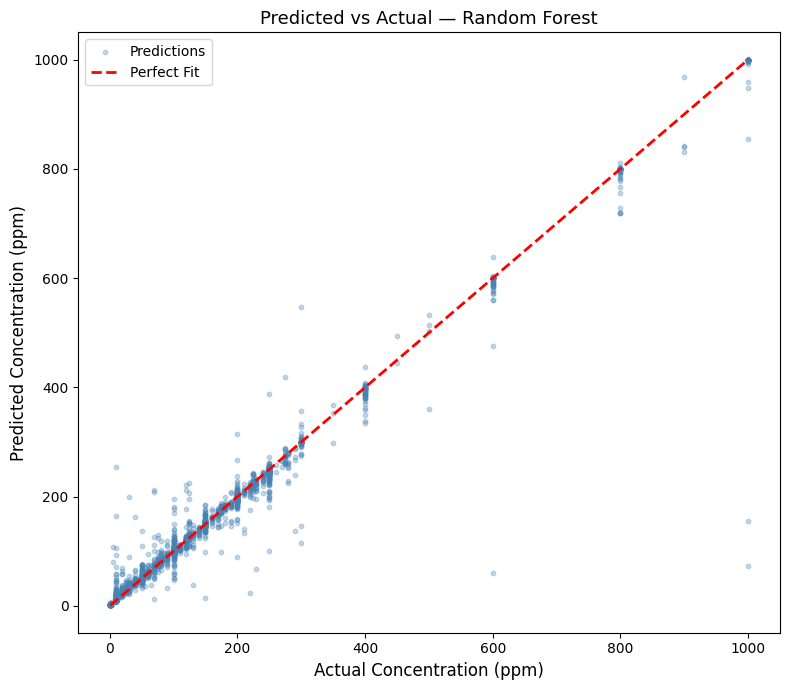

In [82]:
plt.figure(figsize=(8, 7))

plt.scatter(y_test, best_preds, alpha=0.3, s=10, color="steelblue", label="Predictions")

# Perfect prediction diagonal
lo = min(float(y_test.min()), float(best_preds.min()))
hi = max(float(y_test.max()), float(best_preds.max()))
plt.plot([lo, hi], [lo, hi], "r--", linewidth=2, label="Perfect Fit")

plt.xlabel("Actual Concentration (ppm)", fontsize=12)
plt.ylabel("Predicted Concentration (ppm)", fontsize=12)
plt.title(f"Predicted vs Actual — {best_model_name}", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

### Visualisation 2 — Residual Plot (Best Model)

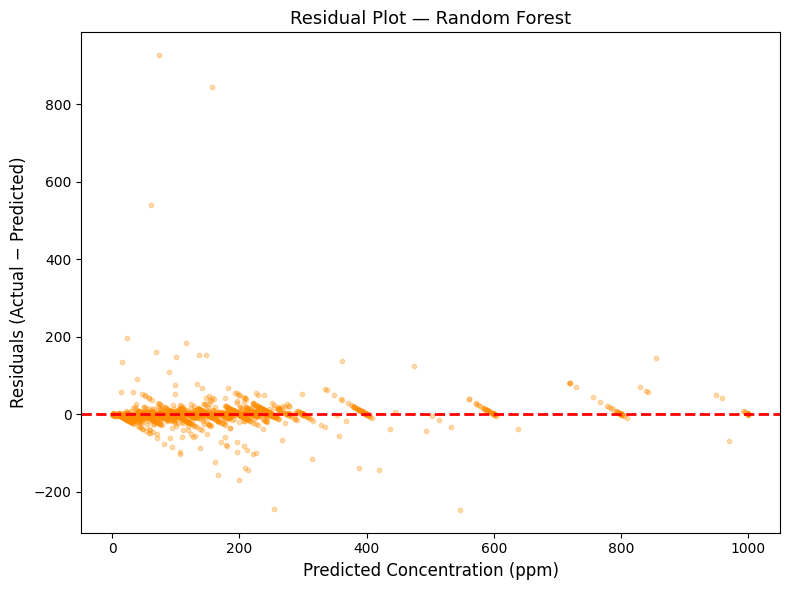

In [83]:
residuals = y_test.values - best_preds

plt.figure(figsize=(8, 6))
plt.scatter(best_preds, residuals, alpha=0.3, s=10, color="darkorange")
plt.axhline(y=0, color="red", linestyle="--", linewidth=2)
plt.xlabel("Predicted Concentration (ppm)", fontsize=12)
plt.ylabel("Residuals (Actual − Predicted)", fontsize=12)
plt.title(f"Residual Plot — {best_model_name}", fontsize=13)
plt.tight_layout()
plt.show()

### Visualisation 3 — Feature Importance (Random Forest)

Tree-based feature importances from the Random Forest model.
Shows which of the 129 features (128 sensor features + SensorMean) are most useful.

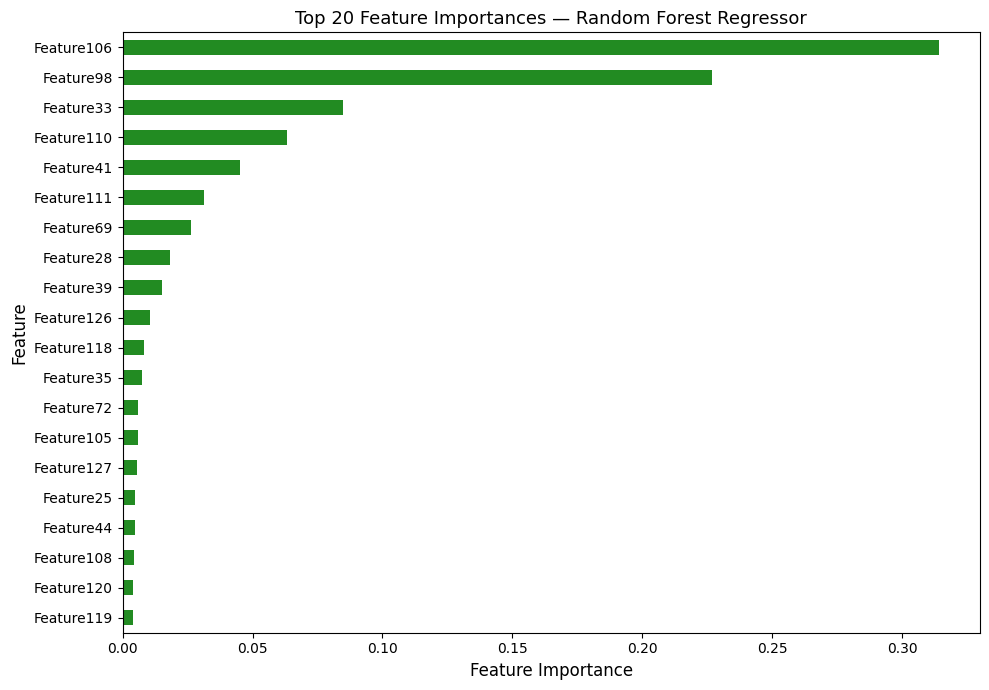

Top 10 most important features:
Feature106    0.314127
Feature98     0.226769
Feature33     0.084712
Feature110    0.063186
Feature41     0.045352
Feature111    0.031216
Feature69     0.026516
Feature28     0.018089
Feature39     0.015238
Feature126    0.010398


In [84]:
importances = pd.Series(
    random_forest_model.feature_importances_,
    index=all_feature_columns
).sort_values(ascending=False)

# Top 20
top20 = importances.head(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind="barh", color="forestgreen")
plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Top 20 Feature Importances — Random Forest Regressor", fontsize=13)
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(importances.head(10).to_string())

## 7. Preliminary Comparison

All 10 models ranked by R² on the same held-out test set.

In [ ]:
# Sort by R² descending
sorted_results = results_df.sort_values(by="R²", ascending=False).reset_index(drop=True)
sorted_results.index = sorted_results.index + 1  # rank starts at 1

print("========== PRELIMINARY COMPARISON (ranked by R²) ==========\n")
display(sorted_results)

========== PRELIMINARY COMPARISON (ranked by R²) ==========



,Model,R²,RMSE,MAE
1,Random Forest,0.9650,32.1499,8.0571
2,KNN,0.9644,32.4200,5.8344
3,Gradient Boosting,0.9467,39.6589,20.7150
4,Decision Tree,0.9458,40.0041,8.8588
5,Ridge Regression,0.9020,53.7906,32.0707
6,Lasso Regression,0.8759,60.5331,30.4398
7,ElasticNet Regression,0.8583,64.6823,35.9070
8,SVR,0.8398,68.7731,33.8427
9,Linear Regression,0.8192,73.0633,27.4257
10,Polynomial Regression,-38.9171,1085.5221,86.6865


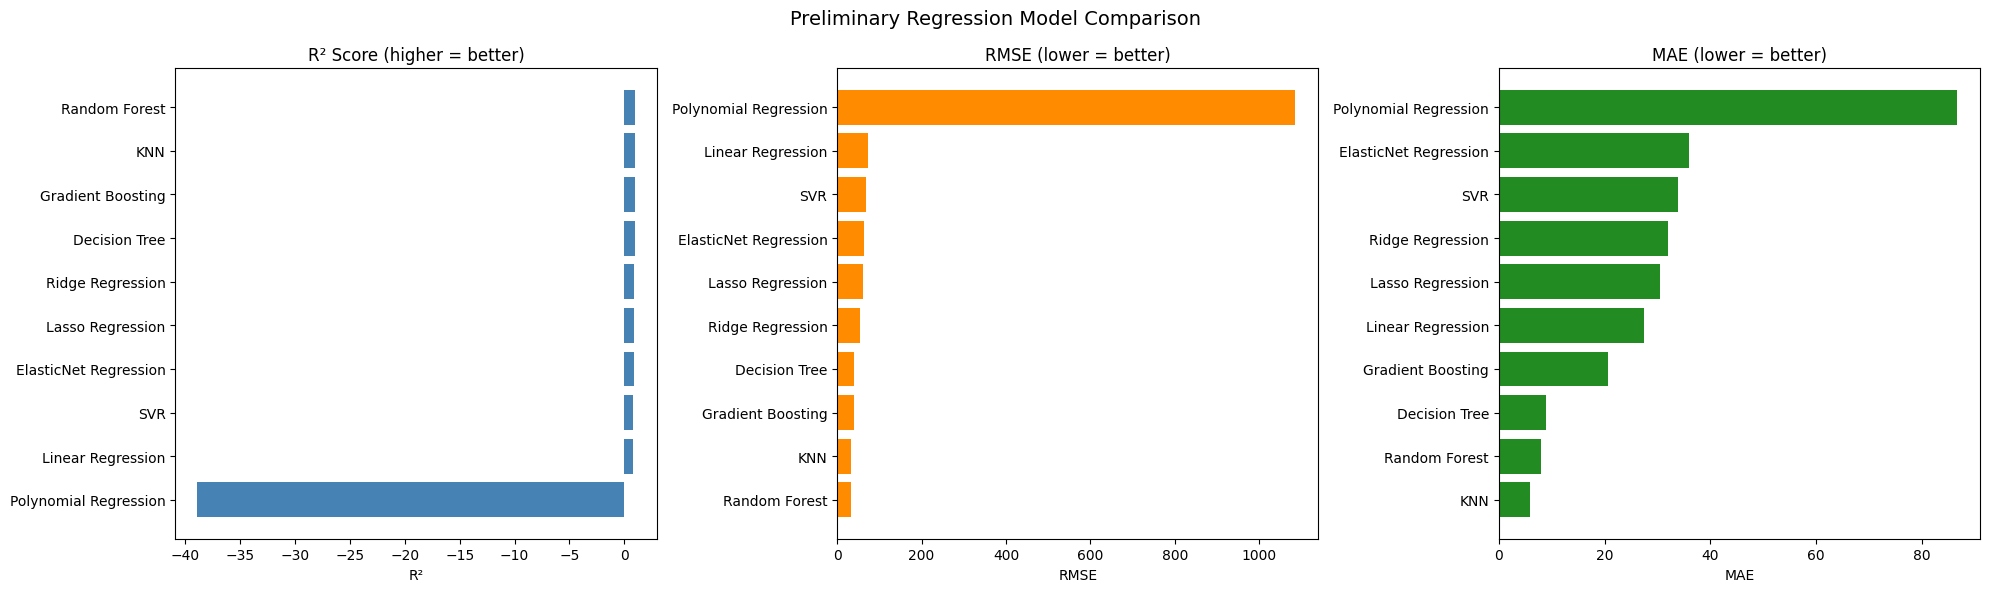

In [86]:
# Comparison bar charts for all three metrics
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

r2_data   = sorted_results.sort_values("R²",   ascending=False)
rmse_data = sorted_results.sort_values("RMSE",  ascending=True)
mae_data  = sorted_results.sort_values("MAE",   ascending=True)

axes[0].barh(r2_data["Model"],   r2_data["R²"],     color="steelblue")
axes[0].set_xlabel("R²")
axes[0].set_title("R² Score (higher = better)")
axes[0].invert_yaxis()

axes[1].barh(rmse_data["Model"], rmse_data["RMSE"], color="darkorange")
axes[1].set_xlabel("RMSE")
axes[1].set_title("RMSE (lower = better)")

axes[2].barh(mae_data["Model"],  mae_data["MAE"],   color="forestgreen")
axes[2].set_xlabel("MAE")
axes[2].set_title("MAE (lower = better)")

plt.suptitle("Preliminary Regression Model Comparison", fontsize=14)
plt.tight_layout()
plt.show()

In [87]:
# The top 2 models by R² — will be tuned and cross-validated
top2_names = sorted_results["Model"].iloc[:2].tolist()
print("Top 2 models selected for tuning and cross-validation:")
for rank, name in enumerate(top2_names, 1):
    print(f"  {rank}. {name}")

Top 2 models selected for tuning and cross-validation:
  1. Random Forest
  2. KNN


## 8. Hyperparameter Tuning

The **two best-performing models by R²** are Random Forest and KNN Regressor (determined dynamically from the comparison table above).

All tuning uses the **training data only** — the test set is never seen during tuning.
For each model we report:
- Best parameters found
- Baseline R², RMSE, MAE (from Section 6)
- Tuned R², RMSE, MAE (on the same held-out test set)
- Improvement


### Tuning Model 1: Random Forest — RandomizedSearchCV


In [ ]:
# Baseline metrics (already computed)
rf_baseline = evaluate_regressor("Random Forest (Baseline)", y_test, random_forest_preds)
print("Random Forest — Baseline:")
print(f"  R²:   {rf_baseline['R²']}")
print(f"  RMSE: {rf_baseline['RMSE']}")
print(f"  MAE:  {rf_baseline['MAE']}")

Random Forest — Baseline:
  R²:   0.965
  RMSE: 32.1499
  MAE:  8.0571


In [ ]:
rf_param_dist = {
    "n_estimators":      [50, 100, 200],
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train_scaled, y_train)

print("Random Forest — Best parameters:", rf_search.best_params_)
print("Best CV R² (training folds):      ", round(rf_search.best_score_, 4))

Random Forest — Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}
Best CV R² (training folds):       0.9765


In [90]:
rf_tuned_preds = rf_search.best_estimator_.predict(X_test_scaled)
rf_tuned = evaluate_regressor("Random Forest (Tuned)", y_test, rf_tuned_preds)

print("Random Forest — Tuning Results:")
print(f"  Baseline R²:   {rf_baseline['R²']:>8}  →  Tuned R²:   {rf_tuned['R²']}")
print(f"  Baseline RMSE: {rf_baseline['RMSE']:>8}  →  Tuned RMSE: {rf_tuned['RMSE']}")
print(f"  Baseline MAE:  {rf_baseline['MAE']:>8}  →  Tuned MAE:  {rf_tuned['MAE']}")
print(f"  R² improvement: {rf_tuned['R²'] - rf_baseline['R²']:+.4f}")

Random Forest — Tuning Results:
  Baseline R²:      0.965  →  Tuned R²:   0.9653
  Baseline RMSE:  32.1499  →  Tuned RMSE: 32.0039
  Baseline MAE:    8.0571  →  Tuned MAE:  8.0074
  R² improvement: +0.0003


### Tuning Model 2: KNN Regressor — GridSearchCV


In [91]:
# Baseline metrics for KNN (already computed in Section 6)
knn_baseline = evaluate_regressor("KNN (Baseline)", y_test, knn_preds)
print("KNN — Baseline metrics:")
print(f"  R²:   {knn_baseline['R²']}")
print(f"  RMSE: {knn_baseline['RMSE']}")
print(f"  MAE:  {knn_baseline['MAE']}")


KNN — Baseline metrics:
  R²:   0.9644
  RMSE: 32.42
  MAE:  5.8344


In [92]:
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15]
}

knn_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid=knn_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

knn_search.fit(X_train_scaled, y_train)

print("KNN — Best k (n_neighbors):", knn_search.best_params_["n_neighbors"])
print("Best CV R² (training folds): ", round(knn_search.best_score_, 4))


KNN — Best k (n_neighbors): 3
Best CV R² (training folds):  0.9789


In [93]:
knn_tuned_preds = knn_search.best_estimator_.predict(X_test_scaled)
knn_tuned = evaluate_regressor("KNN (Tuned)", y_test, knn_tuned_preds)

print("KNN — Tuning Results:")
print(f"  Baseline R²:   {knn_baseline['R²']:>8}  →  Tuned R²:   {knn_tuned['R²']}")
print(f"  Baseline RMSE: {knn_baseline['RMSE']:>8}  →  Tuned RMSE: {knn_tuned['RMSE']}")
print(f"  Baseline MAE:  {knn_baseline['MAE']:>8}  →  Tuned MAE:  {knn_tuned['MAE']}")
print(f"  R² improvement: {knn_tuned['R²'] - knn_baseline['R²']:+.4f}")


KNN — Tuning Results:
  Baseline R²:     0.9644  →  Tuned R²:   0.9644
  Baseline RMSE:    32.42  →  Tuned RMSE: 32.42
  Baseline MAE:    5.8344  →  Tuned MAE:  5.8344
  R² improvement: +0.0000


In [94]:
# Tuning summary table
tuning_table = pd.DataFrame([
    {
        "Model":         "Random Forest",
        "Method":        "RandomizedSearchCV",
        "Baseline R²":   rf_baseline["R²"],
        "Tuned R²":      rf_tuned["R²"],
        "Baseline RMSE": rf_baseline["RMSE"],
        "Tuned RMSE":    rf_tuned["RMSE"],
        "Baseline MAE":  rf_baseline["MAE"],
        "Tuned MAE":     rf_tuned["MAE"],
        "Best Params":   str(rf_search.best_params_)
    },
    {
        "Model":         "KNN",
        "Method":        "GridSearchCV",
        "Baseline R²":   knn_baseline["R²"],
        "Tuned R²":      knn_tuned["R²"],
        "Baseline RMSE": knn_baseline["RMSE"],
        "Tuned RMSE":    knn_tuned["RMSE"],
        "Baseline MAE":  knn_baseline["MAE"],
        "Tuned MAE":     knn_tuned["MAE"],
        "Best Params":   str(knn_search.best_params_)
    },
])

print("========== HYPERPARAMETER TUNING SUMMARY ==========")
display(tuning_table)


========== HYPERPARAMETER TUNING SUMMARY ==========


,Model,Method,Baseline R²,Tuned R²,Baseline RMSE,Tuned RMSE,Baseline MAE,Tuned MAE,Best Params
0,Random Forest,RandomizedSearchCV,0.9650,0.9653,32.1499,32.0039,8.0571,8.0074,"{'n_estimators': 200, 'min_samples_split': 2, ..."
1,KNN,GridSearchCV,0.9644,0.9644,32.4200,32.4200,5.8344,5.8344,{'n_neighbors': 3}


## 9. Cross-Validation of Best Models

**5-fold cross-validated R²** is computed for the two best models on the **training data**.
This tests model generalisation across different random splits of the training set,
independent of the held-out test set.

In [95]:
print("========== 5-FOLD CROSS-VALIDATION: Random Forest (Tuned) ==========\n")

rf_cv_scores = cross_val_score(
    rf_search.best_estimator_,
    X_train_scaled, y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Fold R² scores:", [round(s, 4) for s in rf_cv_scores])
print(f"Mean R²:         {rf_cv_scores.mean():.4f}")
print(f"Std deviation:   {rf_cv_scores.std():.4f}")

========== 5-FOLD CROSS-VALIDATION: Random Forest (Tuned) ==========

Fold R² scores: [np.float64(0.9797), np.float64(0.9751), np.float64(0.9791), np.float64(0.9729), np.float64(0.9805)]
Mean R²:         0.9775
Std deviation:   0.0029


In [96]:
print("========== 5-FOLD CROSS-VALIDATION: KNN (Tuned) ==========\n")

knn_cv_scores = cross_val_score(
    knn_search.best_estimator_,
    X_train_scaled, y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Fold R² scores:", [round(s, 4) for s in knn_cv_scores])
print(f"Mean R²:         {knn_cv_scores.mean():.4f}")
print(f"Std deviation:   {knn_cv_scores.std():.4f}")


========== 5-FOLD CROSS-VALIDATION: KNN (Tuned) ==========

Fold R² scores: [np.float64(0.9835), np.float64(0.9793), np.float64(0.9747), np.float64(0.9758), np.float64(0.9813)]
Mean R²:         0.9789
Std deviation:   0.0033


In [97]:
# Cross-validation summary table
cv_table = pd.DataFrame([
    {
        "Model":      "Random Forest (Tuned)",
        "Fold 1 R²":  round(rf_cv_scores[0], 4),
        "Fold 2 R²":  round(rf_cv_scores[1], 4),
        "Fold 3 R²":  round(rf_cv_scores[2], 4),
        "Fold 4 R²":  round(rf_cv_scores[3], 4),
        "Fold 5 R²":  round(rf_cv_scores[4], 4),
        "CV Mean R²": round(rf_cv_scores.mean(), 4),
        "CV Std":     round(rf_cv_scores.std(), 4)
    },
    {
        "Model":      "KNN (Tuned)",
        "Fold 1 R²":  round(knn_cv_scores[0], 4),
        "Fold 2 R²":  round(knn_cv_scores[1], 4),
        "Fold 3 R²":  round(knn_cv_scores[2], 4),
        "Fold 4 R²":  round(knn_cv_scores[3], 4),
        "Fold 5 R²":  round(knn_cv_scores[4], 4),
        "CV Mean R²": round(knn_cv_scores.mean(), 4),
        "CV Std":     round(knn_cv_scores.std(), 4)
    },
])

print("========== 5-FOLD CV SUMMARY ==========")
display(cv_table)


========== 5-FOLD CV SUMMARY ==========


,Model,Fold 1 R²,Fold 2 R²,Fold 3 R²,Fold 4 R²,Fold 5 R²,CV Mean R²,CV Std
0,Random Forest (Tuned),0.9797,0.9751,0.9791,0.9729,0.9805,0.9775,0.0029
1,KNN (Tuned),0.9835,0.9793,0.9747,0.9758,0.9813,0.9789,0.0033


## 10. Final Regression Comparison

Complete comparison table showing baseline and (where applicable) tuned metrics for all 10 models.
5-fold CV R² is shown for the two best models.

In [ ]:
# Build final comparison table
final_rows = []

cv_r2_map = {
    "Random Forest": round(rf_cv_scores.mean(), 4),
    "KNN":           round(knn_cv_scores.mean(), 4)
}

tuned_r2_map = {
    "Random Forest": rf_tuned["R²"],
    "KNN":           knn_tuned["R²"]
}
tuned_rmse_map = {
    "Random Forest": rf_tuned["RMSE"],
    "KNN":           knn_tuned["RMSE"]
}
tuned_mae_map = {
    "Random Forest": rf_tuned["MAE"],
    "KNN":           knn_tuned["MAE"]
}

for _, row in results_df.iterrows():
    name = row["Model"]
    entry = {
        "Model":               name,
        "Baseline R²":         row["R²"],
        "Baseline RMSE":       row["RMSE"],
        "Baseline MAE":        row["MAE"],
        "Tuned R²":            tuned_r2_map.get(name, "-"),
        "Tuned RMSE":          tuned_rmse_map.get(name, "-"),
        "Tuned MAE":           tuned_mae_map.get(name, "-"),
        "CV Mean R² (5-fold)": cv_r2_map.get(name, "-")
    }
    final_rows.append(entry)

final_df = (
    pd.DataFrame(final_rows)
    .sort_values(by="Baseline R²", ascending=False)
    .reset_index(drop=True)
)
final_df.index = final_df.index + 1

print("========== FINAL REGRESSION COMPARISON ==========")
display(final_df)


KNN — Tuning Results:
  Baseline R²:     0.9644  →  Tuned R²:   0.9644
  Baseline RMSE:    32.42  →  Tuned RMSE: 32.42
  Baseline MAE:    5.8344  →  Tuned MAE:  5.8344
  R² improvement: +0.0000


In [99]:
# Identify the overall best model (comparing tuned versions where available)
all_r2_candidates = []

for _, row in results_df.iterrows():
    all_r2_candidates.append((row["Model"] + " (Baseline)", row["R²"]))

all_r2_candidates.append(("Random Forest (Tuned)", rf_tuned["R²"]))
all_r2_candidates.append(("KNN (Tuned)",           knn_tuned["R²"]))

winner_name, winner_r2 = max(all_r2_candidates, key=lambda x: x[1])

print("=" * 55)
print(" FINAL VERDICT")
print("=" * 55)
print(f" Best Regression Model:  {winner_name}")
print(f" Best R²:                {winner_r2}")
print()
print(f" Tuning improved Random Forest? {'Yes' if rf_tuned['R²'] > rf_baseline['R²'] else 'No/Marginal'}")
print(f" Tuning improved KNN?           {'Yes' if knn_tuned['R²'] > knn_baseline['R²'] else 'No/Marginal'}")
print("=" * 55)


 FINAL VERDICT
 Best Regression Model:  Random Forest (Tuned)
 Best R²:                0.9653

 Tuning improved Random Forest? Yes
 Tuning improved KNN?           No/Marginal
